(02-05-crsp-tape)=

# De CRSP-tape: data als machine

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1959–1968, met een naspel tot 1999.

**Wat we al weten.** [Markowitz, Roy en Tobin](#01-04-markowitz) gaven een
theorie van keuze die draait op $\boldsymbol{\mu}$ en $\boldsymbol{\Sigma}$, en
lieten zien dat die theorie strandt op de invoer: verwachte rendementen zijn
slecht meetbaar. [De lecture over rendementen](#00-01-rendementen) had het
eerste getal al nagebouwd dat ooit over die invoer werd gerapporteerd — de 9,0%
van Fisher en Lorie — met een standaardfout van bijna vier procentpunt erbij.
Wat daar stilzwijgend werd aangenomen, is dat "het rendement van de markt" een
welbepaald getal is dat alleen nog gemeten hoeft te worden.

**Welke vraag staat open.** Wat doet de *constructie* van een
rendementsdatabase — dividenden, splitsingen, verdwenen bedrijven, weging —
met de getallen die we eruit halen?
```

## Overzicht

In 1959 stelde Louis Engel, vicepresident van Merrill Lynch, Pierce, Fenner &
Smith, een vraag die niemand kon beantwoorden: als je met een dartpijl een
willekeurig aandeel aan de New York Stock Exchange raakt, hoe groot is dan de
kans dat je er op lange termijn geld aan verdient, en hoeveel? Hij legde de vraag
voor aan James Lorie van de Graduate School of Business in Chicago. Lorie
antwoordde dat het antwoord niet bestond, omdat de data niet bestond, en stelde
voor dat Merrill Lynch het verzamelen van de historische data zou betalen die
nodig waren om het uit te rekenen. Volgens de geschiedenis die
CRSP zelf publiceert, begon het Center for Research in Security Prices in 1960
met een subsidie van 50.000 dollar (andere bronnen noemen hogere bedragen voor
het hele project). Lorie en Lawrence Fisher lieten maandprijzen, dividenden en
kapitaalmutaties van alle gewone aandelen aan de NYSE vanaf januari 1926
verzamelen, controleren en op magneetband zetten. De resultaten verschenen in
januari 1964 in *The Journal of Business* {cite}`FisherLorie1964`; in 1968 volgde
het jaar-voor-jaaroverzicht tot 1965 {cite}`FisherLorie1968`. In 1962 was Standard
& Poor's al begonnen met *Compustat* (een database met boekhoudcijfers van
beursgenoteerde bedrijven), zodat er vanaf het midden van de jaren zestig twee
machines naast elkaar stonden: een voor koersen en een voor balansen.

Dat werk definieert het tijdvak omdat alles wat in Deel II volgt — de efficiënte
markt, de event study, de toetsen van het CAPM — er rechtstreeks op draait. De
epistemische status is die van een meetinstrument: hier wordt geen theorie
getoetst en geen feit verklaard. Maar een meetinstrument is een verzameling
beslissingen, en elke beslissing heeft een teken — voorspelbaar, en soms groter
dan de standaardfout van 2% waar de reeks omheen is gebouwd.

We definiëren wat een rendement in een database is, leiden de omvang af van
ontbrekende delisting returns, *survivorship bias* (vertekening doordat alleen
bedrijven worden gemeten die de steekproef overleefden) en *look-ahead bias*
(vertekening doordat een strategie informatie gebruikt die op het beslismoment nog
niet bestond), en van het verschil tussen value- en equal-weighted gemiddelden.
Daarna repliceren we op de French-data wat weging met een eeuw marktrendement
doet, en toetsen we de getallen van {cite:t}`Shumway1997` en
{cite:t}`ShumwayWarther1999` over delisting returns en de size-anomalie aan de
afgeleide formule.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Engels vraag lijkt eenvoudig. Neem alle aandelen van 1926, volg ze tot vandaag,
en tel. Maar zodra je het probeert, stelt de data vier vragen terug.

De eerste: wat is "het rendement" van een aandeel? Een koers die van 60 naar 33
gaat is een verlies van 45% — tenzij het bedrijf die maand elk aandeel in twee
heeft gesplitst, want dan heeft de houder er twee van 33 en een winst van 10%. En
een koersdaling op de dag van een dividenduitkering is geen verlies maar een
verplaatsing van geld naar de aandeelhouder.

De tweede: welke aandelen tellen mee? Een bedrijf dat failliet gaat, verdwijnt van
de beurs. Wie in 2026 de lijst van genoteerde bedrijven opvraagt en die
terugrekent tot 1926, meet alleen de winnaars van een eeuw selectie: bedrijven die
veel dalen, raken de drempel waaronder ze worden geschrapt, en de overlevers zijn
per definitie de bedrijven die dat nooit overkwam.

De derde is subtieler. Ook als de verdwenen bedrijven erin staan, ontbreekt vaak
de *delisting return* (het rendement tussen de laatste beurskoers en de waarde die
de houder na schrapping nog realiseert). Bij faillissementen is die groot en
negatief, en juist dan ontbreekt hij het vaakst. Omdat faillissementen vooral
kleine bedrijven treffen, is dat een geschenk aan kleine aandelen.

De vierde: hoe middel je? Een gemiddelde waarin elk bedrijf even zwaar weegt,
wordt gedomineerd door duizenden kleine bedrijven, en is bovendien een strategie
die elke maand winnaars verkoopt en verliezers bijkoopt.

Geen van die vier keuzes voegt ruis toe. Ze voegen een *bias* toe, met een teken
dat je vooraf kunt voorspellen. En dat maakt ze in één opzicht gevaarlijker dan
de standaardfout van 2%: meer jaren data maken een standaardfout kleiner, maar
een bias niet. Een eeuw data met een vertekening van drie procentpunt geeft een
nauwkeurig verkeerd antwoord.

## Toy-voorbeeld: vijf aandelen, vier perioden

Vijf aandelen, prijzen op $t = 0, \dots, 4$. Aandeel A keert in periode 3 een
dividend van 2 uit. Aandeel B splitst in periode 2 twee-voor-één. Aandeel C gaat in
periode 3 failliet: de laatste beurskoers is 6 op $t=2$, en na schrapping is het
aandeel op de onderhandse markt nog 1,50 waard; daarna bestaat het niet meer.

| aandeel | $t=0$ | $t=1$ | $t=2$ | $t=3$ | $t=4$ | gebeurtenis |
|---|---|---|---|---|---|---|
| A | 40 | 44 | 44 | 42 | 46,20 | dividend 2 in periode 3 |
| B | 60 | 60 | 33 | 33 | 29,70 | split 2:1 in periode 2 |
| C | 10 | 8 | 6 | (1,50) | — | delisting in periode 3 |
| D | 50 | 50 | 55 | 55 | 60,50 | — |
| E | 25 | 30 | 30 | 30 | 27 | — |

**De rendementen per aandeel.** Voor A in periode 3 is het totaalrendement
$(42 + 2)/44 - 1 = 0\%$; het prijsrendement zou $42/44 - 1 = -4{,}55\%$ zijn. Voor
B in periode 2 is het ongecorrigeerde prijsrendement $33/60 - 1 = -45\%$, maar met
aanpassingsfactor 2 is het $2 \times 33/60 - 1 = +10\%$. Voor C in periode 3 is
het rendement de delisting return $1{,}50/6 - 1 = -75\%$. De overige rendementen
volgen direct uit de prijzen:

| periode | A | B | C | D | E |
|---|---|---|---|---|---|
| 1 | +10% | 0% | −20% | 0% | +20% |
| 2 | 0% | +10% | −25% | +10% | 0% |
| 3 | 0% | 0% | −75% | 0% | 0% |
| 4 | +10% | −10% | — | +10% | −10% |

**Vier markten.** Het equal-weighted marktrendement per periode, op vier manieren.
*Correct*: alle aandelen die aan het begin van de periode bestaan, met
aanpassingsfactor en delisting return. *Zonder split-aanpassing*: B krijgt in
periode 2 $-45\%$. *Zonder delisting return*: C ontbreekt in periode 3. *Alleen
overlevers*: C ontbreekt in álle perioden, want wie in $t=4$ de lijst van
genoteerde bedrijven opvraagt, ziet C niet meer.

Periode 1, correct: $(10 + 0 - 20 + 0 + 20)/5 = 2{,}0\%$. Overlevers:
$(10 + 0 + 0 + 20)/4 = 7{,}5\%$.
Periode 2, correct: $(0 + 10 - 25 + 10 + 0)/5 = -1{,}0\%$. Zonder split-aanpassing:
$(0 - 45 - 25 + 10 + 0)/5 = -12{,}0\%$. Overlevers: $(0 + 10 + 10 + 0)/4 = 5{,}0\%$.
Periode 3, correct: $-75/5 = -15{,}0\%$. Zonder delisting return en bij de
overlevers: $0/4 = 0{,}0\%$.
Periode 4: C bestaat niet meer, en alle vier de constructies geven
$(10 - 10 + 10 - 10)/4 = 0{,}0\%$.

| constructie | per. 1 | per. 2 | per. 3 | per. 4 | gemiddeld | cumulatief |
|---|---|---|---|---|---|---|
| correct | 2,0% | −1,0% | −15,0% | 0,0% | −3,50% | −14,17% |
| zonder split-aanpassing | 2,0% | −12,0% | −15,0% | 0,0% | −6,25% | −23,70% |
| zonder delisting return | 2,0% | −1,0% | 0,0% | 0,0% | +0,25% | +0,98% |
| alleen overlevers | 7,5% | 5,0% | 0,0% | 0,0% | +3,13% | +12,88% |

Het cumulatieve rendement volgt uit het product van de bruto rendementen. Correct:
$1{,}02 \times 0{,}99 \times 0{,}85 = 0{,}8583$, dus $-14{,}17\%$. Zonder
delisting return: $1{,}02 \times 0{,}99 = 1{,}0098$, dus $+0{,}98\%$. Overlevers:
$1{,}075 \times 1{,}05 = 1{,}12875$, dus $+12{,}88\%$.

Dezelfde vijf aandelen, en de "markt" heeft verloren of gewonnen afhankelijk van
drie boekhoudkundige beslissingen. De split-fout is spectaculair maar onschuldig:
een koers die zonder nieuws halveert, valt op. De twee andere fouten zijn
onzichtbaar, want ze bestaan uit ontbrekende waarnemingen, en ze hebben hetzelfde
teken: allebei maken ze de markt beter dan hij was. De theorie hieronder laat zien
dat dat geen toeval is.

In [2]:
periods = [1, 2, 3, 4]
prices = pd.DataFrame(
    {"A": [40, 44, 44, 42, 46.2], "B": [60, 60, 33, 33, 29.7],
     "C": [10, 8, 6, np.nan, np.nan], "D": [50, 50, 55, 55, 60.5],
     "E": [25, 30, 30, 30, 27]},
    index=range(5), dtype=float,
)
dividends = pd.DataFrame(0.0, index=range(5), columns=prices.columns)
dividends.loc[3, "A"] = 2.0
split = pd.DataFrame(1.0, index=range(5), columns=prices.columns)
split.loc[2, "B"] = 2.0          # shares per old share, applied in period 2
delisting_value = {"C": (3, 1.50)}  # value after delisting, realised in period 3


def total_returns(prices, dividends, split, delisting_value, adjust=True):
    """Holding-period returns with dividends, split factors and delisting returns."""
    factor = split if adjust else pd.DataFrame(1.0, index=split.index, columns=split.columns)
    ret = (prices * factor + dividends) / prices.shift(1) - 1
    for stock, (t, value) in delisting_value.items():
        ret.loc[t, stock] = value / prices.loc[t - 1, stock] - 1
    return ret.loc[periods]


correct = total_returns(prices, dividends, split, delisting_value)
no_split = total_returns(prices, dividends, split, delisting_value, adjust=False)
no_delist = correct.copy()
no_delist.loc[3, "C"] = np.nan
survivors = correct.drop(columns="C")

markets = pd.DataFrame(
    {"correct": correct.mean(axis=1), "zonder split-aanpassing": no_split.mean(axis=1),
     "zonder delisting return": no_delist.mean(axis=1), "alleen overlevers": survivors.mean(axis=1)}
)
toy = pd.concat(
    [markets.T, markets.mean().rename("gemiddeld"), (1 + markets).prod().sub(1).rename("cumulatief")],
    axis=1,
)
hand = np.array([[0.02, -0.01, -0.15, 0.0, -0.035, -0.141667],
                 [0.02, -0.12, -0.15, 0.0, -0.0625, -0.237040],
                 [0.02, -0.01, 0.00, 0.0, 0.0025, 0.009800],
                 [0.075, 0.05, 0.00, 0.0, 0.03125, 0.128750]])
print("code == handberekening:", np.allclose(toy.to_numpy(), hand, atol=5e-6))
print("prijsrendement A, periode 3:", round(prices.loc[3, "A"] / prices.loc[2, "A"] - 1, 4))
toy.round(5)

code == handberekening: True
prijsrendement A, periode 3: -0.0455


,1,2,3,4,gemiddeld,cumulatief
correct,0.020,-0.01,-0.15,0.0,-0.03500,-0.14167
zonder split-aanpassing,0.020,-0.12,-0.15,0.0,-0.06250,-0.23704
zonder delisting return,0.020,-0.01,0.00,0.0,0.00250,0.00980
alleen overlevers,0.075,0.05,0.00,0.0,0.03125,0.12875


De code bouwt de rendementen uit prijzen, dividenden, splitfactoren en de
waarde na delisting, zoals een database dat doet, en komt op exact dezelfde
getallen als de handberekening.

## Theorie

### Rendement in een database

We gebruiken de notatie van de reeks, met één toevoeging. Naast de prijs $p_t$ en
het dividend $d_{t+1}$ (per aandeel dat op $t$ werd gehouden) is er een
*aanpassingsfactor* $k_{t+1}$: het aantal aandelen dat de houder op $t+1$ bezit per
aandeel dat hij op $t$ had. Een 2:1-split heeft $k=2$, een stockdividend van 5%
heeft $k = 1{,}05$, en in een gewone maand is $k = 1$.

*Waarom zou dit waar zijn?* Een rendement meet wat er gebeurt met de euro's van
een houder die niets doet. Die houder ontvangt dividend in contanten en krijgt bij
een split extra stukken; zijn vermogen op $t+1$ is dus $k_{t+1} p_{t+1} + d_{t+1}$
per aandeel dat hij op $t$ kocht voor $p_t$. Alles wat volgt is de definitie van
"niets doen" netjes opschrijven.

:::{prf:definition} Totaalrendement en aanpassingsfactor
:label: def-crsp-tape-totaal

Het bruto totaalrendement van een aandeel tussen $t$ en $t+1$ is

```{math}
:label: eq-crsp-tape-totaal
R_{t+1} = \frac{k_{t+1}\, p_{t+1} + d_{t+1}}{p_t} .
```

De *cumulatieve aanpassingsfactor* is $K_t = \prod_{s \le t} k_s$, en de
*aangepaste prijs* $\tilde p_t = K_t\, p_t$. Het prijsrendement is
$\tilde p_{t+1}/\tilde p_t$; het verschil met [](#eq-crsp-tape-totaal) is het
dividendrendement $d_{t+1}/p_t$. De *total return index* is
$V_T = V_0 \prod_{t=1}^{T} R_t$.
:::

CRSP slaat precies deze componenten op: de ruwe prijs, de uitkeringen met hun
ex-datum, en een cumulatieve factor. De total return index neemt bovendien aan
dat het dividend wordt herbelegd — een keuze, geen feit, en het verschil tussen
de 9,0% en de 6,9% van Fisher en Lorie uit [](#00-01-rendementen). En een
*reverse split* ($k = 0{,}1$, tien aandelen worden er één) is typisch voor een
bedrijf dat zijn koers boven de noteringsdrempel wil houden; wie de factor
vergeet, ziet $+900\%$ bij een bedrijf dat aan het doodgaan is.

### Delistings en de ontbrekende delisting return

Stel dat een aandeel in de loop van periode $t+1$ van de beurs wordt geschrapt.
De laatste beurskoers is $p^{\text{laatst}}$, en de houder realiseert daarna nog
een waarde $v$ (een overnameprijs, een liquidatie-uitkering, of een koers op de
onderhandse markt). Dan is het rendement over de periode

```{math}
:label: eq-crsp-tape-delisting
R_{t+1} = \frac{p^{\text{laatst}}}{p_t} \cdot \frac{v}{p^{\text{laatst}}}
       = \left(1 + r^{\text{deel}}_{t+1}\right)\left(1 + r^{\text{DL}}_{t+1}\right),
```

met $r^{\text{deel}}$ het rendement tot de laatste handelsdag en
$r^{\text{DL}} = v/p^{\text{laatst}} - 1$ de delisting return. De CRSP-bestanden
bevatten $r^{\text{DL}}$ als apart veld; {cite:t}`Shumway1997` liet zien dat dat
veld voor de meeste schrappingen om prestatieredenen sinds 1962 leeg was.

*Waarom zou dit waar zijn?* Een ontbrekende waarneming is alleen onschuldig als
het ontbreken niets met de waarde te maken heeft. Bij delistings ontbreken juist
de rendementen van bedrijven die net failliet zijn, de laagste van de maand. De
vertekening moet dus gelijk zijn aan de kans op zo'n waarneming maal hoe ver ze
onder de rest ligt.

:::{prf:theorem} Bias door ontbrekende delisting returns
:label: thm-crsp-tape-delisting

Beschouw een equal-weighted portefeuille van $N$ aandelen in periode $t+1$. Elk
aandeel wordt onafhankelijk, met kans $h$ gegeven de informatie op $t$, geschrapt
met rendement $D$ over de periode; anders heeft het rendement $R^{a}$ met
$\E_t[R^{a}] = \mu_a$, onafhankelijk van de schrapping. De database registreert
voor geschrapte aandelen geen rendement, en het gerapporteerde
portefeuillerendement is het gemiddelde over de aandelen mét rendement. Dan geldt
voor $N \to \infty$

```{math}
:label: eq-crsp-tape-delistingbias
\plim \bar R^{\text{database}}_{t+1} - \plim \bar R^{\text{waar}}_{t+1}
  = h\,\left(\mu_a - D\right) ,
```

en voor een value-weighted portefeuille wordt $h$ vervangen door
$\sum_i w_{i,t} h_i$, het marktwaardegewogen gemiddelde van de
schrappingskansen.
:::

:::{prf:proof}
Het ware gemiddelde is $N^{-1}\sum_i R_{i,t+1}$ en convergeert naar
$(1-h)\mu_a + hD$. Het databasegemiddelde is een gemiddelde over de
$(1-h)N$ overlevers, waarvan de rendementen door de onafhankelijkheid van
schrapping en $R^{a}$ nog steeds verwachting $\mu_a$ hebben; het convergeert naar
$\mu_a$. Het verschil is $\mu_a - (1-h)\mu_a - hD = h(\mu_a - D)$. Voor de
value-weighted versie herhaal je het argument met gewichten $w_{i,t}$, die op $t$
vastliggen. $\square$
:::

Omdat $\mu_a$ per maand in de orde van een procent is en $D$ in de orde van
$-30\%$ tot $-100\%$, is de bias in goede benadering $h\,|D|$: de maandelijkse
schrappingskans maal het ontbrekende verlies. De bias is dus *geconcentreerd waar
$h$ groot is*, bij kleine aandelen, en daarmee een fout in de cross-sectie en niet
alleen in het niveau. Voor value-weighted portefeuilles is hij vrijwel afwezig,
omdat $w_{i,t}$ klein is precies waar $h_i$ groot is. In de replicatie rekenen we
er de gepubliceerde correcties van Shumway mee na.

### Survivorship: selectie op overleven

Survivorship bias is het extreme geval van dezelfde selectie. Nu ontbreekt niet
alleen het laatste rendement, maar de hele geschiedenis van elk bedrijf dat vóór
het einde van de steekproef verdween.

*Waarom zou dit waar zijn?* Een bedrijf wordt geschrapt als zijn waarde onder een
drempel zakt. Wie overleeft, heeft die drempel nooit geraakt, en dat is informatie
over zijn rendementen. Hoe dichter bij de drempel en hoe volatieler, hoe strenger
de selectie. Dat zijn precies de kleine bedrijven: een steekproef van overlevers
maakt kleine aandelen mooier dan grote.

We maken dat exact in het eenvoudigste model waarin het kan. Laat
$X_t = x_0 + \sigma W_t$ de log-afstand tot de schrappingsdrempel zijn, met $W$ een
standaard Brownse beweging en $x_0 > 0$; het bedrijf wordt geschrapt op
$\tau = \inf\{t : X_t = 0\}$. Er is geen drift, dus het ware verwachte
logrendement is nul.

:::{prf:theorem} Survivorship bias bij een absorberende drempel
:label: thm-crsp-tape-survivorship

In het model hierboven is de kans om tot $T$ te overleven

```{math}
:label: eq-crsp-tape-overleefkans
P(\tau > T) = 2\,\Phi\!\left(\frac{x_0}{\sigma\sqrt{T}}\right) - 1 ,
```

en het gemiddelde logrendement per jaar van de overlevers is

```{math}
:label: eq-crsp-tape-survivorship
\frac{\E\left[X_T - x_0 \mid \tau > T\right]}{T}
  = \frac{x_0}{T}\left(\frac{1}{P(\tau > T)} - 1\right) > 0 .
```

Voor $T \to \infty$ geldt bovendien

```{math}
:label: eq-crsp-tape-survivorlimiet
\frac{\E\left[X_T - x_0 \mid \tau > T\right]}{T} \;\sim\; \sqrt{\frac{\pi}{2}}\;\frac{\sigma}{\sqrt{T}} .
```
:::

:::{prf:proof}
Voor [](#eq-crsp-tape-overleefkans): volgens het reflectieprincipe is
$P(\tau \le T) = 2\,P(\sigma W_T \le -x_0) = 2\,\Phi(-x_0/(\sigma\sqrt T))$, en
$1 - 2\Phi(-z) = 2\Phi(z) - 1$.

Voor [](#eq-crsp-tape-survivorship): $X_t$ is een martingaal en $T \wedge \tau$ een
begrensde stoptijd, dus volgens de optional-stopping-stelling
$\E[X_{T\wedge\tau}] = x_0$. Op $\{\tau \le T\}$ is $X_{T\wedge\tau} = X_\tau = 0$,
dus

$$
x_0 = \E\left[X_T \mathbf{1}\{\tau > T\}\right]
    = \E\left[X_T \mid \tau > T\right] P(\tau > T) .
$$

Delen door $P(\tau > T)$, $x_0$ aftrekken en door $T$ delen geeft het resultaat.

Voor de limiet: met $z = x_0/(\sigma\sqrt T) \to 0$ is
$2\Phi(z) - 1 = 2\varphi(0)\,z + O(z^3) = \sqrt{2/\pi}\,z + O(z^3)$, dus
$1/P(\tau>T) - 1 \sim \sqrt{\pi/2}\,\sigma\sqrt{T}/x_0$. Vermenigvuldigen met
$x_0/T$ geeft [](#eq-crsp-tape-survivorlimiet). $\square$
:::

Alle informatie over de selectie zit in één getal, de overleefkans. Een klein
bedrijf met $x_0 = 1$ (een koers van ongeveer 2,7 keer de drempel) en
$\sigma = 50\%$ per jaar overleeft twintig jaar met kans
$2\Phi(0{,}447) - 1 = 0{,}345$, en de overlevers hebben een gemiddeld
logrendement van $(1/20)(1/0{,}345 - 1) = 9{,}5\%$ per jaar, terwijl het ware
verwachte rendement nul is. Een groot bedrijf met $x_0 = 3$ en $\sigma = 20\%$
overleeft met kans 0,9992, en de bias is een honderdste procentpunt. Een
steekproef van overlevers maakt dus uit het niets een size-premie van negen
procentpunt.

In [3]:
def survivor_bias(x0, sigma, horizon):
    """Survival probability and survivors' mean log return per year (driftless, barrier at 0)."""
    p_survive = 2 * stats.norm.cdf(x0 / (sigma * np.sqrt(horizon))) - 1
    return p_survive, x0 / horizon * (1 / p_survive - 1)


pd.DataFrame(
    [survivor_bias(1.0, 0.50, 20), survivor_bias(3.0, 0.20, 20)],
    index=["klein: x0=1, sigma=50%", "groot: x0=3, sigma=20%"],
    columns=["overleefkans", "bias gem. logrendement per jaar"],
).round(5)

,overleefkans,bias gem. logrendement per jaar
"klein: x0=1, sigma=50%",0.34528,0.09481
"groot: x0=3, sigma=20%",0.99920,0.00012


{cite:t}`BrownGoetzmannIbbotsonRoss1992` maakten hetzelfde punt voor
beleggingsfondsen: als fondsen na slechte resultaten verdwijnen, lijken de
prestaties van de overlevers ook *persistent*, en hun numerieke voorbeelden
lieten zien dat die afkapping sterk genoeg kan zijn om het toenmalige bewijs voor
voorspelbare fondsprestaties te verklaren. Het mechanisme is dat van
[](#thm-crsp-tape-survivorship): selectie op overleven maakt het gemiddelde een
stijgende functie van de volatiliteit.

```{warning}
Vergelijk [](#eq-crsp-tape-survivorlimiet) met de standaardfout van het
gemiddelde logrendement van één aandeel over $T$ jaar, $\sigma/\sqrt{T}$. De bias
krimpt met precies dezelfde snelheid en blijft ongeveer $1{,}25$ standaardfout.
Middel je over veel aandelen, dan krimpt de standaardfout met het aantal aandelen
en de bias niet. Bij ruis helpt meer data; bij selectie niet.
```

### Look-ahead: informatie die er nog niet was

*Waarom zou dit waar zijn?* Een strategie is alleen een strategie als iemand haar
op het beslismoment had kunnen uitvoeren. Een sortering op marktwaarde aan het
*einde* van de maand gebruikt het rendement dat de portefeuille moet verklaren: de
kleinste aandelen aan het einde van de maand zijn deels de aandelen die die maand
crashten.

Formeel: laat $\mathcal{F}_t$ de informatie op $t$ zijn. Een strategie met
gewichten $w_{i,t}$ is uitvoerbaar als elk $w_{i,t}$ $\mathcal{F}_t$-meetbaar is.
Sorteren op $\log \mathrm{ME}_{i,t+1} = \log \mathrm{ME}_{i,t} + \log R_{i,t+1}$
schendt die voorwaarde, en omdat $\Cov(\log \mathrm{ME}_{i,t+1}, R_{i,t+1}) > 0$
per constructie, is de bias van het teken dat kleine portefeuilles slechter lijken.
In de simulatie hieronder draait dat de size-premie om.

In boekhouddata is de look-ahead minder zichtbaar. Een jaarrekening over boekjaar
$t$ is op 31 december van $t$ nog niet gepubliceerd; Fama en French koppelen
boekhoudcijfers over boekjaar $t-1$ daarom pas aan rendementen vanaf juli van
jaar $t$ {cite}`FamaFrench1992`. En als Compustat een bedrijf toevoegt, voegt het
vaak ook eerdere jaren toe, maar alleen voor bedrijven die dan nog bestaan.
{cite:t}`KothariShankenSloan1995` vermoedden dat een deel van de waardepremie
daardoor komt: Compustat bevat onevenredig veel bedrijven met een hoge
book-to-market die hun financiële nood overleefden. De database weet in 1965 al
welke bedrijven er in 1980 nog zijn.

### Value-weighted, equal-weighted en de rebalancing-bonus

Een value-weighted portefeuille houdt elk aandeel naar zijn marktwaarde,
$w_{i,t} = \mathrm{ME}_{i,t}/\sum_j \mathrm{ME}_{j,t}$. Een equal-weighted
portefeuille houdt elk aandeel met gewicht $1/N_t$.

*Waarom zou dit waar zijn?* Het verschil is een verschil in strategie. De
value-weighted portefeuille is buy-and-hold: een aandeel dat stijgt, krijgt vanzelf
meer gewicht. De equal-weighted portefeuille moet elke maand winnaars afromen en
verliezers bijkopen. Wie volatiele posities steeds terugzet naar een vast gewicht,
verkoopt hoog en koopt laag, en haalt een meetkundige groei boven het gemiddelde
van die van de onderdelen.

Twee resultaten. Het eerste is een identiteit voor het *rekenkundige* verschil.
Met $\bar R_{t+1} = N^{-1}\sum_i R_{i,t+1}$ en omdat $\sum_i (w_{i,t} - 1/N) = 0$:

```{math}
:label: eq-crsp-tape-ewvw
R^{\text{EW}}_{t+1} - R^{\text{VW}}_{t+1}
  = \sum_i \left(\tfrac{1}{N} - w_{i,t}\right) R_{i,t+1}
  = -N \cdot \Cov_{\text{cs}}\!\left(w_{i,t},\, R_{i,t+1}\right) ,
```

met $\Cov_{\text{cs}}$ de covariantie over de aandelen in één periode. Het
rekenkundige verschil *is* dus een size-premie. Het tweede resultaat gaat over de
*meetkundige* groei {cite}`BoothFama1992`.

:::{prf:theorem} Diversificatierendement van een geherbalanceerde portefeuille
:label: thm-crsp-tape-rebalancing

Laat $N$ aandelen de prijsdynamiek $dS_i/S_i = \mu_i\,dt + \sigma_i\,dW_i$ hebben,
met $d\langle W_i, W_j\rangle = \rho_{ij}\,dt$. Een portefeuille die continu
geherbalanceerd wordt naar vaste gewichten $w_i$ heeft meetkundige groeivoet
$g_p = \sum_i w_i\mu_i - \tfrac12\sigma_p^2$, met
$\sigma_p^2 = \sum_{i,j} w_i w_j \rho_{ij}\sigma_i\sigma_j$. Het verschil met het
gewogen gemiddelde van de groeivoeten $g_i = \mu_i - \tfrac12\sigma_i^2$ van de
onderdelen is

```{math}
:label: eq-crsp-tape-bonus
g_p - \sum_i w_i g_i = \tfrac12\left(\sum_i w_i \sigma_i^2 - \sigma_p^2\right) \;\ge\; 0 ,
```

en bij gelijke gewichten, gelijke $\sigma_i = \sigma$ en gelijke $\rho_{ij} = \rho$
is dit $\tfrac12\sigma^2(1-\rho)(1 - 1/N)$.
:::

:::{prf:proof}
De waarde $V$ van de geherbalanceerde portefeuille voldoet aan
$dV/V = \sum_i w_i\, dS_i/S_i = \sum_i w_i\mu_i\,dt + \sum_i w_i\sigma_i\,dW_i$,
een meetkundige Brownse beweging met driftvoet $\sum_i w_i\mu_i$ en
variantievoet $\sigma_p^2$. Itô op $\log V$ geeft
$d\log V = (\sum_i w_i\mu_i - \tfrac12\sigma_p^2)\,dt + \sum_i w_i\sigma_i\,dW_i$,
dus $g_p$ zoals gesteld; idem $g_i$ voor elk aandeel. Aftrekken geeft
[](#eq-crsp-tape-bonus). De ongelijkheid is Cauchy-Schwarz:
$\sigma_p^2 \le (\sum_i w_i\sigma_i)^2 \le \sum_i w_i\sigma_i^2$, de laatste
stap door de convexiteit van $x \mapsto x^2$. Invullen van de symmetrische
parameters geeft
$\sigma_p^2 = \sigma^2(\rho + (1-\rho)/N)$ en dus
$\tfrac12(\sigma^2 - \sigma_p^2) = \tfrac12\sigma^2(1-\rho)(1-1/N)$. $\square$
:::

Met $\sigma = 50\%$ voor een typisch klein aandeel en $\rho = 0{,}2$ is dat
$\tfrac12 \times 0{,}25 \times 0{,}8 = 10\%$ per jaar meetkundige groei boven het
gemiddelde van de onderdelen. Dat is geen verwacht rendement dat de markt betaalt —
het rekenkundige verwachte rendement blijft $\sum_i w_i\mu_i$ — maar het verklaart
waarom een equal-weighted index over een eeuw veel meer eindvermogen kan tonen.

Een derde, minder onschuldig mechanisme treft alleen de equal-weighted
portefeuille. Een slotkoers ligt op de bied- of de laatkoers, niet op de "ware"
prijs. Stel $p^{o}_t = p_t(1+\delta_t)$ met $\delta_t$ onafhankelijk, gemiddelde
nul en variantie $s^2$. Dan is het gemeten bruto rendement
$R^{o}_{t+1} = R_{t+1}(1+\delta_{t+1})/(1+\delta_t)$, en uit
$1/(1+\delta) = 1 - \delta + \delta^2 - \dots$ volgt

$$
\E\left[R^{o}_{t+1}\right] \approx \E\left[R_{t+1}\right]\left(1 + s^2\right) .
$$

Elk maandrendement is dus met ongeveer $s^2$ naar boven vertekend. Bij een
bid-ask spread van 10% van de koers is $\delta = \pm 5\%$ en $s^2 = 0{,}25\%$ per
maand: drie procentpunt per jaar. Een equal-weighted portefeuille die elke maand
het gemiddelde van die rendementen neemt, erft die bias volledig; een
buy-and-hold-portefeuille alleen via het begin- en eindpunt. {cite:t}`BlumeStambaugh1983`
lieten zien dat het jaarlijkse size-effect op basis van buy-and-hold-rendementen
half zo groot is als eerder gerapporteerd, en dat het restant gemiddeld volledig
in januari zit.

```{note}
Ontbrekende delisting returns, survivorship, de rebalancing-bonus en de bid-ask
bias maken allemaal equal-weighted rendementen van kleine aandelen hoger dan een
uitvoerbare belegging oplevert; alleen look-ahead op het sorteermoment werkt de
andere kant op. Wie een size-premie meet, meet nooit alleen een size-premie.
```

## Simulatie: een universum met faillissementen

De theorie gaf de biases per stuk, in modellen die exact op te lossen waren. De
simulatie zet ze in één universum dat op een aandelenmarkt lijkt en vraagt hoe
groot ze samen zijn in *steekproeven*, vergeleken met de steekproefruis.

**Het model.** Er zijn 1000 aandelen, 30 jaar maanddata, en 100 onafhankelijke
steekproeven. Elk aandeel heeft een log-marktwaarde $x_{i,t}$. De kans op
schrapping in maand $t+1$ hangt af van hoe klein het aandeel is ten opzichte van
het doorsnee aandeel,

$$
h_{i,t} = \frac{0{,}02}{1 + \exp\!\left(\left(x_{i,t} - \bar x_t + 2\right)/0{,}5\right)} ,
$$

zodat de kleinste aandelen tot 2% per maand kans op schrapping hebben. Een
geschrapt aandeel heeft over de maand rendement $D = -30\%$, het gemiddelde dat
{cite:t}`Shumway1997` voor NYSE/AMEX vond, en wordt vervangen door een nieuwe,
kleine notering. De overige aandelen hebben rendement
$R_{i,t+1} = (1+\mu_{i,t}) \exp(f_{t+1} + \varepsilon_{i,t+1} - \tfrac12(\sigma_m^2 +
\sigma_\varepsilon^2))$, met een marktschok $f$ ($\sigma_m = 4{,}5\%$ per maand)
en een idiosyncratische schok $\varepsilon$ ($\sigma_\varepsilon = 12\%$ per
maand).

**De cruciale keuze.** De drift is zó gekozen dat het *ware* verwachte rendement,
inclusief de schrappingskans, voor elk aandeel exact 1% per maand is:
$(1-h)(1+\mu) + h(1+D) = 1{,}01$, dus $\mu = (0{,}01 - hD)/(1-h)$. **Er is in dit
universum per constructie geen size-premie.** Alles wat we wel meten, komt uit de
database.

We meten de rendementen van tien size-decielen (gesorteerd op $x_{i,t}$ aan het
begin van de maand) op vier manieren: correct; zonder delisting returns
(geschrapte aandelen vallen die maand weg); alleen overlevers (alleen de
aandelen die aan het einde van de dertig jaar nog genoteerd zijn, vanaf hun
notering); en met look-ahead (gesorteerd op marktwaarde aan het *einde* van de
maand).

In [4]:
def size_deciles(key, mask):
    """Decile (0 = smallest) of `key` within `mask`, row by row."""
    n_rows, n_cols = key.shape
    order = np.argsort(np.where(mask, key, np.inf), axis=1)
    ranks = np.empty_like(order)
    np.put_along_axis(ranks, order, np.broadcast_to(np.arange(n_cols), (n_rows, n_cols)), axis=1)
    count = mask.sum(axis=1, keepdims=True)
    return np.minimum(ranks * 10 // np.maximum(count, 1), 9)


def decile_mean(values, decile, mask):
    """Equal-weighted mean of `values` per decile among `mask`, row by row."""
    n_rows = decile.shape[0]
    flat = (np.arange(n_rows)[:, None] * 10 + decile)[mask]
    sums = np.bincount(flat, weights=values[mask], minlength=n_rows * 10)
    counts = np.bincount(flat, minlength=n_rows * 10)
    return (sums / np.maximum(counts, 1)).reshape(n_rows, 10)


def hazard(x, h_max):
    """Monthly delisting probability, high for stocks far below the median size."""
    relative = x - x.mean(axis=1, keepdims=True)
    return h_max / (1 + np.exp((relative + 2.0) / 0.5))


def simulate(gen, n_sims, n_stocks, n_months, h_max=0.02, m=0.01, sigma_m=0.045,
             sigma_i=0.12, delist_ret=-0.30, last_delist=None):
    """Simulate a listed universe with delistings and replacement listings.

    Pass 1 (``last_delist=None``) only records, per slot, the month of the last
    delisting.  Pass 2 replays the same random numbers and uses that record to
    build the survivors-only sample, which needs knowledge of the sample's end.
    """
    x = gen.normal(0.0, 1.5, size=(n_sims, n_stocks))
    last = np.full((n_sims, n_stocks), -1)
    full = np.ones((n_sims, n_stocks), dtype=bool)
    deciles = {k: np.zeros((n_sims, n_months, 10))
               for k in ("correct", "missing", "survivors", "lookahead", "delist_rate")}
    market = {k: np.zeros((n_sims, n_months))
              for k in ("EW correct", "EW zonder delisting", "EW overlevers", "VW correct", "VW zonder delisting")}
    for t in range(n_months):
        h = hazard(x, h_max)
        mu = (m - h * delist_ret) / (1 - h)
        f = gen.normal(0.0, sigma_m, size=(n_sims, 1))
        eps = gen.normal(0.0, sigma_i, size=(n_sims, n_stocks))
        r = (1 + mu) * np.exp(f + eps - (sigma_m**2 + sigma_i**2) / 2) - 1
        dead = gen.random((n_sims, n_stocks)) < h
        r_true = np.where(dead, delist_ret, r)
        entrant_x = gen.normal(-1.0, 1.0, size=(n_sims, n_stocks)) + x.mean(axis=1, keepdims=True)
        if last_delist is not None:
            alive = ~dead
            surv = (t > last_delist) & alive
            dec = size_deciles(x, full)
            deciles["correct"][:, t] = decile_mean(r_true, dec, full)
            deciles["missing"][:, t] = decile_mean(r_true, dec, alive)
            deciles["delist_rate"][:, t] = decile_mean(dead.astype(float), dec, full)
            deciles["survivors"][:, t] = decile_mean(r_true, size_deciles(x, surv), surv)
            deciles["lookahead"][:, t] = decile_mean(
                r_true, size_deciles(x + np.log1p(r_true), full), full)
            w = np.exp(x)
            market["EW correct"][:, t] = r_true.mean(axis=1)
            market["EW zonder delisting"][:, t] = (r_true * alive).sum(axis=1) / alive.sum(axis=1)
            market["EW overlevers"][:, t] = (r_true * surv).sum(axis=1) / np.maximum(surv.sum(axis=1), 1)
            market["VW correct"][:, t] = (w * r_true).sum(axis=1) / w.sum(axis=1)
            market["VW zonder delisting"][:, t] = (w * r_true * alive).sum(axis=1) / (w * alive).sum(axis=1)
        last = np.where(dead, t, last)
        x = np.where(dead, entrant_x, x + np.log1p(r))
    return last, deciles, market

```{tip}
Een steekproef van overlevers vereist kennis van het einde van de steekproef. De
eerste doorgang onthoudt daarom per positie alleen de maand van de laatste
schrapping; daarna zetten we de toestand van `rng` terug en speelt de tweede
doorgang exact dezelfde trekkingen af.
```

In [5]:
n_sims, n_stocks, n_months, delist_ret = 100, 1000, 360, -0.30

state = rng.bit_generator.state
last_delist, _, _ = simulate(rng, n_sims, n_stocks, n_months, delist_ret=delist_ret)
rng.bit_generator.state = state
_, sim_deciles, sim_market = simulate(rng, n_sims, n_stocks, n_months,
                                      delist_ret=delist_ret, last_delist=last_delist)
print(f"posities zonder schrapping in 30 jaar: {np.mean(last_delist == -1):.1%}")
print(f"schrappingen per jaar (universum): {12 * sim_deciles['delist_rate'].mean():.2%}")

posities zonder schrapping in 30 jaar: 47.6%
schrappingen per jaar (universum): 3.24%


In [6]:
labels = {"correct": "correct", "missing": "zonder delisting return",
          "survivors": "alleen overlevers", "lookahead": "look-ahead sortering"}
annual = {k: 12 * sim_deciles[k].mean(axis=1) for k in labels}   # (n_sims, 10), per steekproef

sim_table = pd.DataFrame(
    {labels[k]: {
        "kleinste deciel": v[:, 0].mean(),
        "grootste deciel": v[:, 9].mean(),
        "size-premie (klein - groot)": (v[:, 0] - v[:, 9]).mean(),
        "SD premie over steekproeven": (v[:, 0] - v[:, 9]).std(ddof=1),
    } for k, v in annual.items()}
).T
sim_table.round(4)

,kleinste deciel,grootste deciel,size-premie (klein - groot),SD premie over steekproeven
correct,0.1234,0.1229,0.0005,0.0103
zonder delisting return,0.1777,0.1229,0.0548,0.0096
alleen overlevers,0.2711,0.1257,0.1454,0.0108
look-ahead sortering,-0.1203,0.2748,-0.3951,0.0097


In [7]:
delist_rate = sim_deciles["delist_rate"].mean(axis=(0, 1))
predicted = 12 * delist_rate / (1 - delist_rate) * (0.01 - delist_ret)
measured = annual["missing"].mean(axis=0) - annual["correct"].mean(axis=0)

check = pd.DataFrame(
    {"schrappingskans per maand": delist_rate,
     "bias gemeten (per jaar)": measured,
     "bias volgens stelling (per jaar)": predicted},
    index=pd.Index(range(1, 11), name="size-deciel"),
)
check.round(4)

,schrappingskans per maand,bias gemeten (per jaar),bias volgens stelling (per jaar)
size-deciel,,,
1,0.0144,0.0543,0.0543
2,0.0067,0.0252,0.0251
3,0.0032,0.0118,0.0118
4,0.0015,0.0056,0.0056
5,0.0007,0.0027,0.0027
6,0.0003,0.0012,0.0012
7,0.0001,0.0005,0.0005
8,0.0000,0.0002,0.0002
9,0.0000,0.0001,0.0001


In [8]:
market_table = pd.DataFrame(
    {"gemiddeld jaarrendement": {k: 12 * v.mean() for k, v in sim_market.items()},
     "SD over steekproeven": {k: 12 * v.mean(axis=1).std(ddof=1) for k, v in sim_market.items()}}
)
market_table.round(4)

,gemiddeld jaarrendement,SD over steekproeven
EW correct,0.1229,0.0272
EW zonder delisting,0.1330,0.0273
EW overlevers,0.1695,0.0278
VW correct,0.1197,0.0301
VW zonder delisting,0.1200,0.0301


In het correct gemeten universum is de size-premie $0{,}05$ procentpunt per jaar,
met een standaarddeviatie over de honderd steekproeven van één procentpunt: nul,
zoals het model voorschrijft. Laat dezelfde database de delisting returns weg, en
het kleinste deciel verdient 17,8% in plaats van 12,3%: een size-premie van 5,5
procentpunt, ruim vijf standaarddeviaties. Neem alleen de overlevers, en de premie
wordt 14,5 procentpunt. Sorteer op de marktwaarde aan het einde van de maand, en
de "premie" wordt $-39{,}5$ procentpunt: de kleinste aandelen aan het einde van de
maand zijn grotendeels de aandelen die die maand zijn ingestort.

De tweede tabel toetst [](#thm-crsp-tape-delisting) deciel voor deciel. In het
kleinste deciel is de schrappingskans 1,44% per maand; de stelling voorspelt
$12 \times 0{,}0144/(1-0{,}0144) \times 0{,}31 = 5{,}43$ procentpunt per jaar en de
simulatie meet 5,43. Vanaf het vijfde deciel is de bias kleiner dan 0,03
procentpunt: hij zit in de rand van het universum, precies waar een
size-sortering kijkt. In het marktrendement ligt equal-weighted zonder delisting
returns een procentpunt te hoog en met alleen overlevers bijna vijf, terwijl
value-weighted nauwelijks verandert (11,97% naar 12,00%). Het universum verliest
3,2% van zijn noteringen per jaar, tussen de 1,2% (NYSE/AMEX) en 5,6% (Nasdaq)
van {cite:t}`ShumwayWarther1999`.

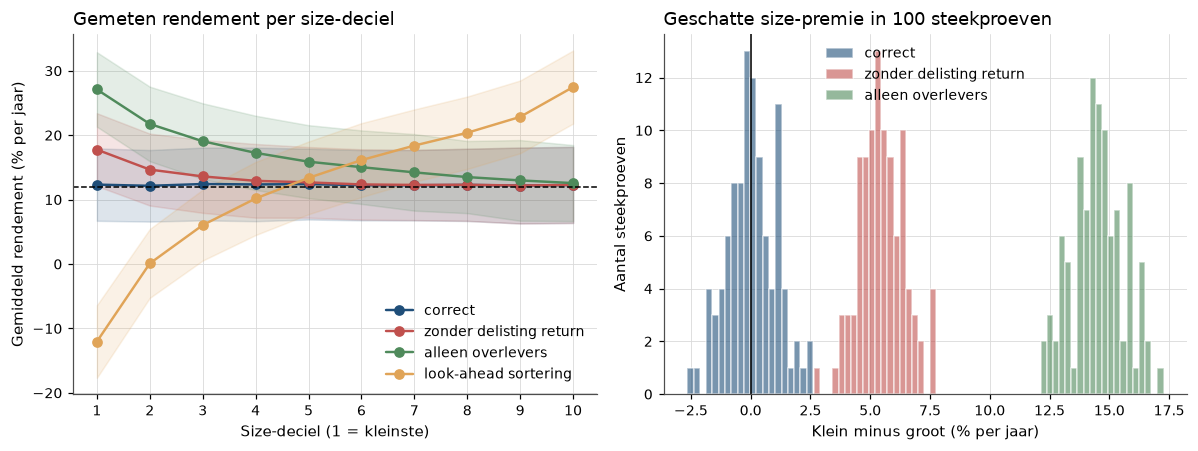

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
deciles_axis = np.arange(1, 11)
for (key, label), color in zip(labels.items(), hap.plotting.COLORS):
    mean = annual[key].mean(axis=0) * 100
    spread = annual[key].std(axis=0, ddof=1) * 100
    axes[0].plot(deciles_axis, mean, marker="o", color=color, label=label)
    axes[0].fill_between(deciles_axis, mean - 2 * spread, mean + 2 * spread, color=color, alpha=0.15)
axes[0].axhline(12, color="black", lw=1, ls="--")
axes[0].set_title("Gemeten rendement per size-deciel")
axes[0].set_xlabel("Size-deciel (1 = kleinste)")
axes[0].set_ylabel("Gemiddeld rendement (% per jaar)")
axes[0].set_xticks(deciles_axis)
axes[0].legend()

for (key, label), color in zip(list(labels.items())[:3], hap.plotting.COLORS):
    premium = (annual[key][:, 0] - annual[key][:, 9]) * 100
    axes[1].hist(premium, bins=20, color=color, alpha=0.6, label=label, edgecolor="white")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Geschatte size-premie in 100 steekproeven")
axes[1].set_xlabel("Klein minus groot (% per jaar)")
axes[1].set_ylabel("Aantal steekproeven")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-crsp-tape-sim
:label: fig-crsp-tape-sim
:width: 100%

Een universum zonder size-premie, vier keer gemeten. Links: het correct gemeten
rendement is in elk deciel 12% (stippellijn), maar zonder delisting returns en
bij alleen overlevers stijgt het rendement naar het kleine eind, en met
look-ahead daalt het; de banden zijn twee standaarddeviaties over de
steekproeven. Rechts: de drie verdelingen van de geschatte premie overlappen
niet. De steekproefruis — het 2%-motief — is hier kleiner dan de bias, en een
$t$-toets op de verkeerde database verwerpt "geen size-premie" in elke
steekproef.
:::

De ruis is in de simulatie kleiner dan in echte data, omdat het model geen
gemeenschappelijke size-factor heeft; in de French-data hieronder is de
standaardfout van de size-premie twee à zes procentpunt. Het punt verandert
daardoor niet: een bias van vijf procentpunt signaleert geen enkele
standaardfout.

## Replicatie op echte data

### Wat weging met een eeuw doet

```{admonition} Replicatie
:class: seealso

**Bron.** Lawrence Fisher & James H. Lorie, *Rates of Return on Investments in
Common Stocks*, The Journal of Business 37(1), 1964 {cite}`FisherLorie1964`, en
*Rates of Return on Investments in Common Stock: The Year-by-Year Record,
1926–65*, The Journal of Business 41(3), 1968 {cite}`FisherLorie1968`.

**Wat.** Het cumulatieve rendement op "alle" Amerikaanse aandelen sinds 1926 —
het product dat de tape als eerste mogelijk maakte. Het getal van 9,0% is al
nagebouwd in [](#00-01-rendementen); hier gaat het om wat de *weging* met die
reeks doet: equal-weighted versus value-weighted, 1926–2026, uitgesplitst naar
size-deciel.

**Data hier.** Kenneth French Data Library via
`hap.data.french("Portfolios_Formed_on_ME", ...)`: de value- en equal-weighted
decielrendementen, het aantal bedrijven per deciel (tabel 4) en de gemiddelde
marktwaarde per deciel (tabel 5); en `hap.data.market_monthly()`. Periode
1926-08 t/m 2026-07.

**Verschil met het origineel.** Fisher en Lorie gebruikten alleen NYSE-aandelen
en gelijke *bedragen* bij aankoop, daarna buy-and-hold; French neemt NYSE, AMEX en
Nasdaq, sorteert op NYSE-breekpunten en herbalanceert equal-weighted maandelijks.
Door die breekpunten is het gemiddelde van de tien decielen niet equal-weighted
over alle bedrijven; dat benaderen we door de decielen te wegen met het aantal
bedrijven van de vorige maand (value-weighted: aantal maal gemiddelde
marktwaarde).

**Verwachte afwijking.** (1) De uit decielen gereconstrueerde value-weighted
markt ligt binnen 0,1 procentpunt per jaar van `Mkt`; wijkt dat meer af, dan
klopt de reconstructie niet. (2) Equal-weighted ligt boven value-weighted,
rekenkundig én meetkundig. (3) Het verschil tussen equal- en value-weighted zit
bijna volledig in het kleinste deciel: daar is het groter dan in elk ander
deciel, en in de vijf grootste decielen is het niet van nul te onderscheiden.
Dat is de rangorde die de theorie voorspelt: ontbrekende delisting returns, de
bid-ask bias en de winst uit het herbalanceren van volatiele posities zijn alle
drie het sterkst bij de kleinste aandelen.
```

In [10]:
deciles = ["Lo 10", "2-Dec", "3-Dec", "4-Dec", "5-Dec", "6-Dec", "7-Dec", "8-Dec", "9-Dec", "Hi 10"]
size_vw = hap_data.french("Portfolios_Formed_on_ME", "monthly")[deciles]
size_ew = hap_data.french("Portfolios_Formed_on_ME", "monthly", table="Equal-Weight")[deciles]
n_firms = hap_data.french("Portfolios_Formed_on_ME", "monthly", table=4)[deciles]
avg_size = hap_data.french("Portfolios_Formed_on_ME", "monthly", table=5)[deciles]
market = hap_data.market_monthly()["Mkt"]

lagged_n = n_firms.shift(1)
lagged_cap = (n_firms * avg_size).shift(1)
ew_all = ((lagged_n * size_ew).sum(axis=1) / lagged_n.sum(axis=1)).dropna()
vw_rebuilt = ((lagged_cap * size_vw).sum(axis=1) / lagged_cap.sum(axis=1)).dropna()

weighting = pd.concat(
    {"VW markt (Mkt)": market, "VW uit decielen": vw_rebuilt, "EW alle bedrijven": ew_all},
    axis=1,
).dropna()


def describe(r):
    """Annualised arithmetic and geometric mean, volatility, SE and terminal wealth."""
    years = len(r) / 12
    vol = r.std(ddof=1) * np.sqrt(12)
    return pd.Series({"rekenkundig": 12 * r.mean(), "meetkundig": (1 + r).prod() ** (1 / years) - 1,
                      "volatiliteit": vol, "SE gemiddelde": vol / np.sqrt(years),
                      "eindwaarde van 1 dollar": (1 + r).prod()})


weighting.apply(describe).T.round(4)

,rekenkundig,meetkundig,volatiliteit,SE gemiddelde,eindwaarde van 1 dollar
VW markt (Mkt),0.1155,0.1033,0.1834,0.0183,18594.3252
VW uit decielen,0.1163,0.1043,0.1829,0.0183,20281.5365
EW alle bedrijven,0.1466,0.1230,0.2505,0.0250,109503.2389


In [11]:
gap = weighting["EW alle bedrijven"] - weighting["VW markt (Mkt)"]
decile_gap = size_ew - size_vw
gap_table = pd.DataFrame(
    {"EW - VW (per jaar)": 12 * decile_gap.mean(),
     "SE": 12 * decile_gap.std(ddof=1) / np.sqrt(len(decile_gap))}
)
gap_table.loc["markt: EW alle - VW"] = [12 * gap.mean(), 12 * gap.std(ddof=1) / np.sqrt(len(gap))]
gap_table["t-waarde"] = gap_table.iloc[:, 0] / gap_table["SE"]
gap_table.round(4)

,EW - VW (per jaar),SE,t-waarde
Lo 10,0.0377,0.0072,5.2185
2-Dec,0.0098,0.0046,2.1474
3-Dec,0.0040,0.0034,1.1756
4-Dec,0.0007,0.0035,0.2034
5-Dec,0.0001,0.0032,0.0195
6-Dec,-0.0000,0.0028,-0.0075
7-Dec,-0.0000,0.0030,-0.0127
8-Dec,-0.0017,0.0027,-0.6370
9-Dec,0.0005,0.0025,0.2080
Hi 10,-0.0016,0.0036,-0.4340


De reconstructie klopt: 11,63% per jaar uit decielen tegen 11,55% voor `Mkt`.
Equal-weighted geeft rekenkundig 14,66% en meetkundig 12,30%, tegen 11,55% en
10,33% voor value-weighted. Het verschil van 3,1 procentpunt per jaar heeft een
standaardfout van 1,2 ($t = 2{,}7$), en één dollar wordt 109.503 dollar in plaats
van 18.594: een factor zes, zonder dat er één aandeel anders is gemeten.

De tweede tabel laat zien waar het verschil vandaan komt. In het kleinste deciel
is equal-weighted 3,77 procentpunt per jaar beter dan value-weighted (standaardfout
0,72), in het tweede 0,98, in het derde 0,40, en vanaf het vierde schommelt het
verschil binnen $\pm 0{,}17$ procentpunt rond nul. Alle drie de verwachtingen uit
het replicatieblok komen uit: het equal-weighted marktrendement is in de eerste
plaats een uitspraak over het kleinste deciel.

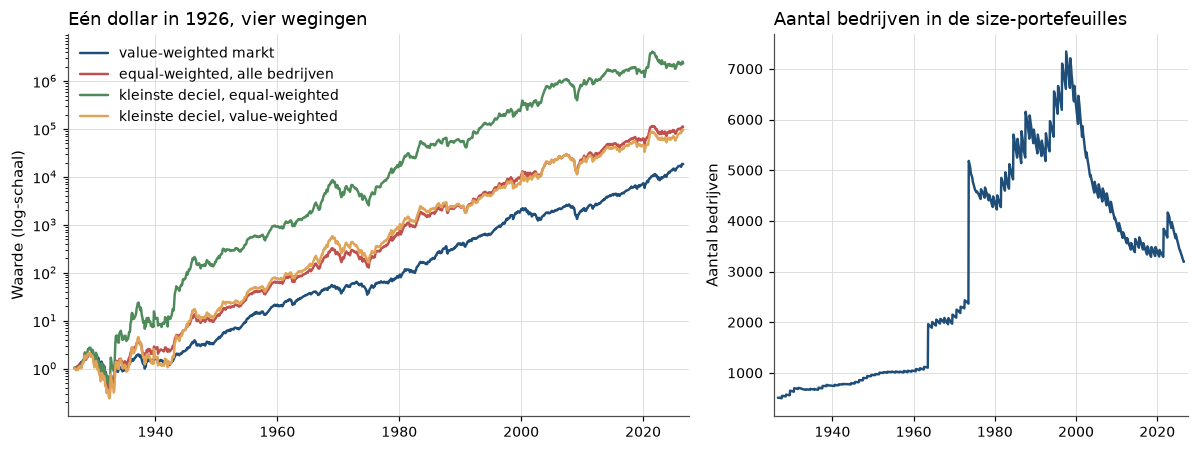

In [12]:
wealth = pd.DataFrame({
    "value-weighted markt": (1 + weighting["VW markt (Mkt)"]).cumprod(),
    "equal-weighted, alle bedrijven": (1 + weighting["EW alle bedrijven"]).cumprod(),
    "kleinste deciel, equal-weighted": (1 + size_ew["Lo 10"].loc[weighting.index]).cumprod(),
    "kleinste deciel, value-weighted": (1 + size_vw["Lo 10"].loc[weighting.index]).cumprod(),
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [3, 2]})
for column, color in zip(wealth.columns, hap.plotting.COLORS):
    axes[0].plot(wealth.index, wealth[column], color=color, label=column)
axes[0].set_yscale("log")
axes[0].set_title("Eén dollar in 1926, vier wegingen")
axes[0].set_xlabel("Jaar")
axes[0].set_ylabel("Waarde (log-schaal)")
axes[0].legend()
hap.plotting.timeline_axis(axes[0])

axes[1].plot(n_firms.index, n_firms.sum(axis=1), color=hap.plotting.COLORS[0])
axes[1].set_title("Aantal bedrijven in de size-portefeuilles")
axes[1].set_xlabel("Jaar")
axes[1].set_ylabel("Aantal bedrijven")
hap.plotting.timeline_axis(axes[1])
fig.tight_layout()
plt.show()

:::{figure} #cel-crsp-tape-weging
:label: fig-crsp-tape-weging
:width: 100%

Links: dezelfde eeuw, vier keer gewogen. Het kleinste deciel equal-weighted
eindigt ruim een orde van grootte boven het kleinste deciel value-weighted — twee
portefeuilles uit dezelfde aandelen, die alleen verschillen in hoe binnen het
deciel wordt gewogen en of er elke maand wordt geherbalanceerd. Rechts: het
universum zelf is geen constante. Het groeide van ruim vijfhonderd bedrijven in
1926 naar een piek van 7343 in juli 1997 en kromp daarna tot 3193; elke daling
in die lijn is een verzameling delistings, en elke delisting is een rendement
dat wel of niet in de database staat.
:::

### Shumway: de delisting return en de size-anomalie

```{admonition} Replicatie
:class: seealso

**Bron.** Tyler Shumway, *The Delisting Bias in CRSP Data*, Journal of Finance
52(1), 1997 {cite}`Shumway1997`; Tyler Shumway & Vincent A. Warther, *The
Delisting Bias in CRSP's Nasdaq Data and Its Implications for the Size Effect*,
Journal of Finance 54(6), 1999 {cite}`ShumwayWarther1999`.

**Wat.** Shumway (1997), tabel V: voor NYSE/AMEX-aandelen die om
prestatieredenen werden geschrapt, is met onderhandse koersen voor 734 bedrijven
(71,3% van de gevallen) een delisting return te reconstrueren, gemiddeld
**−29,9%**. Tabel VII (NYSE, AMEX en Nasdaq, sorteerjaren 1962–1992,
equal-weighted, geannualiseerd): het kleinste size-deciel verdient **21,28%** met
de oorspronkelijke CRSP-data, **19,83%** met de nieuwe delisting returns, en
**16,07%** met $-100\%$ voor elke prestatie-delisting; het grootste deciel
verdient in alle drie de gevallen **11,71%**. Shumway & Warther (1999), tabel IV
(Nasdaq, 1972–1995, twintig size-portefeuilles): in de kleinste portefeuille
wordt **2,95%** van de aandelen per maand geschrapt; het gemiddelde rendement
daalt van **3,79%** naar **1,97%** per maand wanneer ontbrekende delisting
returns op **−55%** worden gezet, en de $F$-toets op gelijke gemiddelden gaat van
**3,52** ($p = 0{,}0001$) naar **0,58** ($p = 0{,}930$). Hun conclusie: na correctie
is er geen bewijs dat er op Nasdaq ooit een size-effect was.

**Data hier.** Er is geen gratis bedrijfsdata met delisting returns. Daarom:
(a) toetsen we de gepubliceerde correcties aan [](#thm-crsp-tape-delisting);
(b) meten we de size-premie in de French-decielen via
`hap.data.french("Portfolios_Formed_on_ME", ...)`, equal- en value-weighted, per
deelperiode; (c) berekenen we welke schrappingskans de gemeten premie volledig
zou wegverklaren. De simulatie hierboven bootst na wat we op bedrijfsniveau niet
zien: een universum met bekende schrappingskans en bekend ontbrekend rendement.

**Verschil met het origineel.** De French-portefeuilles zijn gebouwd op de
huidige CRSP-bestanden, niet op die van 1997. Shumway schreef dat CRSP de
onderhandse koersen als delisting-prijzen zou gaan uitgeven; hoe de huidige
bestanden en de French-constructie met nog ontbrekende delisting returns omgaan,
hebben we niet kunnen verifiëren. Stap (c) is daarom een gedachte-experiment over
de kwetsbaarheid van de premie, geen correctie.

**Verwachte afwijking.** (1) [](#eq-crsp-tape-delistingbias) reproduceert de
gepubliceerde correcties tot op ongeveer 0,2 procentpunt per maand (Nasdaq) en
0,15 procentpunt per jaar (tabel VII). (2) De equal-weighted size-premie is in
elke deelperiode met positieve premie groter dan de value-weighted. (3) Na 1981,
na de publicatie van {cite:t}`Banz1981`, is de premie in beide wegingen niet van
nul te onderscheiden. (4) De schrappingskans die de premie sinds 1963 zou
wegverklaren, ligt tussen het NYSE/AMEX-gemiddelde (1,2% per jaar) en de
frequentie in de kleinste Nasdaq-portefeuille (2,95% per maand).
```

In [13]:
published = pd.DataFrame(
    {
        "gepubliceerde correctie": [3.79 - 1.97, 21.28 - 16.07, 21.28 - 19.83],
        "voorspeld: h x |D|": [2.95 * 0.55, 5.21 * 0.30, np.nan],
        "eenheid": ["pp per maand", "pp per jaar", "pp per jaar"],
    },
    index=[
        "Shumway-Warther tabel IV: kleinste portefeuille, D = -55%",
        "Shumway tabel VII: kleinste deciel, OTC-rendementen (h uit kolom -100%)",
        "Shumway tabel VII: kleinste deciel, OTC-rendementen (gerapporteerd)",
    ],
)
published.round(3)

,gepubliceerde correctie,voorspeld: h x |D|,eenheid
"Shumway-Warther tabel IV: kleinste portefeuille, D = -55%",1.82,1.623,pp per maand
"Shumway tabel VII: kleinste deciel, OTC-rendementen (h uit kolom -100%)",5.21,1.563,pp per jaar
"Shumway tabel VII: kleinste deciel, OTC-rendementen (gerapporteerd)",1.45,NaN,pp per jaar


De eerste regel is de rekensom uit de theorie: 1,62 procentpunt per maand
voorspeld, 1,82 gerapporteerd. De tweede gebruikt alleen Shumways eigen tabel: met
$-100\%$ voor elk ontbrekend rendement daalt het kleinste deciel met 5,21
procentpunt per jaar, en volgens [](#eq-crsp-tape-delistingbias) is dat bij
$\mu_a \approx 0$ de jaarlijkse frequentie van ontbrekende prestatie-delistings.
Met het onderhandse gemiddelde van $-30\%$ voorspelt de stelling dan 1,56
procentpunt; de tabel rapporteert 1,45. Beide correcties vallen binnen de
aangekondigde marge: de hele delisting-bias zit in twee getallen, de
schrappingsfrequentie en het ontbrekende verlies.

In [14]:
subperiods = {"1926-07 / 1962-12": ("1926-07", "1962-12"),
              "1963-01 / 1981-12": ("1963-01", "1981-12"),
              "1982-01 / 2026-07": ("1982-01", "2026-07"),
              "1926-07 / 2026-07": ("1926-07", "2026-07")}


def premium_stats(panel, start, end):
    """Annualised small-minus-big premium, its standard error and t-statistic."""
    p = (panel["Lo 10"] - panel["Hi 10"]).loc[start:end]
    se = p.std(ddof=1) / np.sqrt(len(p))
    return 12 * p.mean(), 12 * se, p.mean() / se


rows = {}
for name, (start, end) in subperiods.items():
    ew_mean, ew_se, ew_t = premium_stats(size_ew, start, end)
    vw_mean, vw_se, vw_t = premium_stats(size_vw, start, end)
    rows[name] = {"EW premie": ew_mean, "EW SE": ew_se, "EW t": ew_t,
                  "VW premie": vw_mean, "VW SE": vw_se, "VW t": vw_t}
size_premium = pd.DataFrame(rows).T
size_premium.round(4)

,EW premie,EW SE,EW t,VW premie,VW SE,VW t
1926-07 / 1962-12,0.1861,0.0640,2.9077,0.1034,0.0585,1.7661
1963-01 / 1981-12,0.1261,0.0430,2.9309,0.0983,0.0410,2.4000
1982-01 / 2026-07,-0.0005,0.0256,-0.0213,-0.0092,0.0236,-0.3884
1926-07 / 2026-07,0.0916,0.0273,3.3514,0.0523,0.0251,2.0865


In [15]:
monthly_premium = (size_ew["Lo 10"] - size_ew["Hi 10"]).loc["1963-01":"2026-07"].mean()
break_even = pd.DataFrame(
    {"schrappingskans per maand": {f"D = {d:.0%}": monthly_premium / -d for d in (-0.30, -0.55, -1.00)},
     "schrappingskans per jaar": {f"D = {d:.0%}": 12 * monthly_premium / -d for d in (-0.30, -0.55, -1.00)}}
)
share_small = n_firms["Lo 10"] / n_firms.sum(axis=1)
print(f"EW size-premie 1963-2026: {monthly_premium:.4%} per maand")
for date in ("1956-07-31", "1976-07-31", "2026-07-31"):
    print(f"aandeel bedrijven in kleinste deciel, {date[:7]}: {share_small.loc[date]:.1%}")
break_even.round(4)

EW size-premie 1963-2026: 0.3109% per maand
aandeel bedrijven in kleinste deciel, 1956-07: 10.0%
aandeel bedrijven in kleinste deciel, 1976-07: 53.6%
aandeel bedrijven in kleinste deciel, 2026-07: 38.6%


,schrappingskans per maand,schrappingskans per jaar
D = -30%,0.0104,0.1244
D = -55%,0.0057,0.0678
D = -100%,0.0031,0.0373


De size-premie gedraagt zich zoals verwacht. Over 1926–1962 is de equal-weighted premie 18,6
procentpunt per jaar ($t = 2{,}9$), de value-weighted 10,3 ($t = 1{,}8$); over
1963–1981 12,6 ($t = 2{,}9$) tegen 9,8 ($t = 2{,}4$). Na 1981 is de premie in beide
wegingen verdwenen: $-0{,}05$ procentpunt equal-weighted en $-0{,}9$ value-weighted,
met standaardfouten van ruim twee procentpunt. Over de volle eeuw is het 9,2
procentpunt equal-weighted en 5,2 value-weighted: het verschil tussen de wegingen
is groter dan de standaardfout van elk van beide.

De omgekeerde rekensom laat zien hoe kwetsbaar dat getal is. De equal-weighted
premie sinds 1963 is 0,31% per maand. Om die volledig met ontbrekende delisting
returns van $-55\%$ te verklaren, zou 0,57% van het kleinste deciel per maand
(6,8% per jaar) zonder geregistreerd laatste rendement moeten verdwijnen; bij
$-30\%$ is dat 1,04% per maand. Shumway en Warther rapporteren voor de kleinste Nasdaq-aandelen
2,95% per maand en voor Nasdaq als geheel 5,6% per jaar; het NYSE/AMEX-gemiddelde
is 1,2% per jaar. Omdat French sorteert op NYSE-breekpunten, viel in 1956 precies
10% van de bedrijven in het kleinste deciel, maar in 1976 ruim de helft en in 2026
nog altijd bijna 40%: het kleinste deciel is sinds de toevoeging van AMEX en
Nasdaq het deel van de beurs waar de kleinste noteringen zich ophopen, en de
benodigde schrappingskans is daar niet exotisch. Of de huidige data die rendementen wel bevatten, kunnen we zonder
CRSP niet vaststellen — en precies dat is het punt: het teken en de omvang van
de meest bestudeerde anomalie van de jaren tachtig hangen af van een veld in een
database dat de gebruiker zelden opent.

## Wat er brak, en wat daarna kwam

**Wat de tape verklaart.** Vóór 1964 was er over het rendement op aandelen geen
meting, alleen een mening; daarna was er een getal met een definitie. Binnen tien
jaar draaiden de toetsen van de random walk, de eerste event study en de toetsen
van het CAPM op dezelfde band. De beslissingen van Fisher en Lorie —
totaalrendementen met herbelegde dividenden, alle genoteerde aandelen inclusief
de verdwenen, vanaf een conjunctuurcyclus vóór 1929 — zijn nog steeds de
standaard, en dat ze de verdwenen bedrijven meenamen was achteraf de
belangrijkste.

**Waar het breekt.** In de velden die leeg bleven, en in de keuzes die de
gebruiker maakt. De replicatie hierboven laat zien dat alleen al de weging het
marktrendement van een eeuw met 3,1 procentpunt per jaar verschuift en de
size-premie met vier, en dat vrijwel het hele verschil in het kleinste deciel
zit. {cite:t}`ShumwayWarther1999` lieten zien dat het size-effect op Nasdaq na het
invullen van de ontbrekende delisting returns verdwijnt: de $F$-toets gaat van
3,52 naar 0,58. Dat is het concrete, meetbare feit: de constructie van de
database is een grotere bron van onzekerheid over de cross-sectie dan de
standaardfout van 2%, en ze valt niet weg als er meer jaren bij komen.

**Risico of vergissing?** Dezelfde correctie laat zich op twee manieren lezen.
In de Chicago-lezing laat de delisting return zien waarom kleine aandelen meer
moeten opbrengen zolang ze bestaan: dat is de vergoeding voor het verlies bij
faillissement — in onze simulatie letterlijk het mechanisme — en wat na correctie
overblijft, is compensatie voor een risico dat de gemiddelde belegger niet wil
dragen. In de Yale-lezing is een size-premie die verdwijnt zodra de data worden
gecorrigeerd, en ook in schone data na publicatie, nooit een risicopremie geweest
maar een artefact of een tijdelijke vergissing; {cite:t}`ShumwayWarther1999`
schrijven zelf dat hun resultaten niet te rijmen zijn met de meeste op risico
gebaseerde verklaringen van het size-effect. Wat de twee zou scheiden, is een
maat voor het faillissementsrisico van kleine bedrijven die onafhankelijk van hun
rendementen wordt gemeten, gecombineerd met volledige delisting returns — en die
data heeft deze reeks niet. Het praktijkmotief zegt het korter: wie een premie
koopt die alleen in een equal-weighted, maandelijks geherbalanceerde portefeuille
zonder delisting returns bestaat, draagt geen beprijsd risico maar denkt iets te
weten wat de prijs niet weet.

**Wat er daarna kwam.** Met de tape in handen kon voor het eerst worden getoetst
of koersen werkelijk geen geheugen hebben — en daarmee begon Fama aan de
hypothese die het decennium zou definiëren: zie [](#02-06-efficiente-markten).

## Oefeningen

:::{exercise}
:label: ex-crsp-tape-1

**Survivorship bij discrete waarneming.** Neem het model van
[](#thm-crsp-tape-survivorship) met $x_0 = 1$, $\sigma = 50\%$ per jaar en
$T = 20$ jaar.

1. Laat zien dat [](#eq-crsp-tape-survivorship) *niet* geldt als $X_t$ een
   drift $\nu \neq 0$ heeft: waar in het bewijs gaat het mis, en welk proces is
   dan wél een martingaal?
2. Simuleer 20 000 paden met maandelijkse stappen en een schrapping zodra
   $X_t \le 0$ op een maandeinde. Vergelijk de overleefkans en het gemiddelde
   logrendement per jaar van de overlevers met de formules.
3. Verklaar het teken van het verschil tussen simulatie en formule.
:::

:::{solution} ex-crsp-tape-1
:class: dropdown

**(1)** Het bewijs gebruikt dat $X_t$ een martingaal is, zodat
$\E[X_{T\wedge\tau}] = x_0$. Met drift is $\E[X_{T\wedge\tau}] = x_0 +
\nu\,\E[T\wedge\tau]$, en die verwachte stoptijd hangt zelf van de drempel af. De
juiste martingaal is dan $X_t - \nu t$, en de conditionele verwachting bevat de
extra term $\nu\,\E[T\wedge\tau]$; de eenvoudige formule is een eigenschap van
het driftloze geval.

**(2) en (3)**

In [16]:
n_paths, steps_per_year, horizon, x0, sigma = 20_000, 12, 20, 1.0, 0.50
increments = rng.normal(0.0, sigma / np.sqrt(steps_per_year), size=(n_paths, steps_per_year * horizon))
paths = x0 + increments.cumsum(axis=1)
alive = (paths > 0).all(axis=1)

p_formula, bias_formula = survivor_bias(x0, sigma, horizon)
pd.DataFrame(
    {"simulatie (maandelijks)": [alive.mean(), (paths[alive, -1].mean() - x0) / horizon],
     "formule (continu)": [p_formula, bias_formula]},
    index=["overleefkans", "gem. logrendement overlevers per jaar"],
).round(4)

,simulatie (maandelijks),formule (continu)
overleefkans,0.3676,0.3453
gem. logrendement overlevers per jaar,0.0928,0.0948


De gesimuleerde overleefkans (0,368) ligt boven de continue formule (0,345) en de
bias (9,3%) eronder (9,5%). Dat is het verwachte teken: een pad dat tussen twee
maandeinden kort onder de drempel duikt, wordt bij maandelijkse waarneming niet
geschrapt, dus de selectie is iets milder. Survivorship bias is geen eigenschap van
één model maar van selectie op een drempel.
:::

:::{exercise}
:label: ex-crsp-tape-2

**Waar zit het verschil tussen EW en VW, en wanneer?** Gebruik `size_ew`,
`size_vw` en de reconstructie `ew_all` uit de replicatie.

1. Bereken voor de drie deelperioden 1926–1962, 1963–1981 en 1982–2026 het
   rekenkundige verschil tussen equal- en value-weighted in het kleinste en in het
   grootste deciel, met standaardfouten.
2. Bereken voor dezelfde deelperioden het verschil in *meetkundig* gemiddelde
   tussen `ew_all` en de value-weighted markt. Is het meetkundige verschil groter
   of kleiner dan het rekenkundige, en wat zegt [](#thm-crsp-tape-rebalancing)
   daarover?
3. Is het verschil tussen equal- en value-weighted in het kleinste deciel na 1981
   verdwenen, zoals de size-premie?
:::

:::{solution} ex-crsp-tape-2
:class: dropdown

In [17]:
rows = {}
vw_market = weighting["VW markt (Mkt)"]
for name, (start, end) in list(subperiods.items())[:3]:
    small = (size_ew["Lo 10"] - size_vw["Lo 10"]).loc[start:end]
    large = (size_ew["Hi 10"] - size_vw["Hi 10"]).loc[start:end]
    ew_part, vw_part = ew_all.loc[start:end], vw_market.loc[start:end]
    years = len(ew_part) / 12
    rows[name] = {
        "Lo 10: EW-VW": 12 * small.mean(), "Lo 10: SE": 12 * small.std(ddof=1) / np.sqrt(len(small)),
        "Hi 10: EW-VW": 12 * large.mean(), "Hi 10: SE": 12 * large.std(ddof=1) / np.sqrt(len(large)),
        "markt rekenk. EW-VW": 12 * (ew_part.mean() - vw_part.mean()),
        "markt meetk. EW-VW": (1 + ew_part).prod() ** (1 / years) - (1 + vw_part).prod() ** (1 / years),
    }
pd.DataFrame(rows).T.round(4)

,Lo 10: EW-VW,Lo 10: SE,Hi 10: EW-VW,Hi 10: SE,markt rekenk. EW-VW,markt meetk. EW-VW
1926-07 / 1962-12,0.0798,0.0143,-0.0029,0.0053,0.0506,0.0326
1963-01 / 1981-12,0.0305,0.0077,0.0026,0.0075,0.0697,0.0650
1982-01 / 2026-07,0.0064,0.0106,-0.0022,0.0060,-0.0014,-0.0102


Het verschil tussen equal- en value-weighted *binnen* het kleinste deciel krimpt
van 8,0 procentpunt per jaar over 1926–1962 (standaardfout 1,4) via 3,1 over
1963–1981 (0,8) tot 0,6 na 1981 (1,1), terwijl het binnen het grootste deciel in
alle drie de perioden binnen drie tienden van een procentpunt rond nul ligt. Het
antwoord op (3) is dus ja: ook het weegverschil binnen het kleinste deciel is na
1981 niet meer van nul te onderscheiden. Krimpende bid-ask spreads en
vollediger delisting returns passen bij dit patroon, maar een verdwijnende
size-premie binnen het deciel ook; deze data kan die twee niet scheiden.

Het meetkundige marktverschil is in elke periode kleiner dan het rekenkundige (na
1981 $-1{,}0$ tegen $-0{,}1$ procentpunt), omdat de volatielere equal-weighted
markt meer variance drag heeft; de bonus van [](#thm-crsp-tape-rebalancing) geldt
ten opzichte van de eigen onderdelen, niet van een andere portefeuille. Elke
uitspraak over "het" marktrendement is dus een uitspraak over een periode én een
weging.
:::

:::{exercise}
:label: ex-crsp-tape-3

**Nasdaq-parameters in de simulatie.** Herhaal de simulatie met de parameters die
{cite:t}`ShumwayWarther1999` voor Nasdaq vonden: een ontbrekend rendement van
$D = -55\%$. Gebruik 40 steekproeven van 20 jaar om de rekentijd te beperken.

1. Hoe groot is nu de bias in het kleinste deciel zonder delisting returns, en
   klopt hij met [](#thm-crsp-tape-delisting)?
2. Hoe groot is de gemeten size-premie zonder delisting returns, uitgedrukt in
   standaarddeviaties over de steekproeven?
3. Waarom verandert de bias van de *overlevers*-steekproef veel minder dan die
   zonder delisting returns wanneer $D$ van $-30\%$ naar $-55\%$ gaat?
:::

:::{solution} ex-crsp-tape-3
:class: dropdown

In [18]:
n_small, months_small, nasdaq_ret = 40, 240, -0.55
state = rng.bit_generator.state
last_nasdaq, _, _ = simulate(rng, n_small, n_stocks, months_small, delist_ret=nasdaq_ret)
rng.bit_generator.state = state
_, nasdaq_deciles, _ = simulate(rng, n_small, n_stocks, months_small,
                                delist_ret=nasdaq_ret, last_delist=last_nasdaq)

annual_nq = {k: 12 * nasdaq_deciles[k].mean(axis=1) for k in ("correct", "missing", "survivors")}
h_small = nasdaq_deciles["delist_rate"][:, :, 0].mean()
premium_nq = {k: v[:, 0] - v[:, 9] for k, v in annual_nq.items()}
pd.DataFrame(
    {"premie": {labels[k]: p.mean() for k, p in premium_nq.items()},
     "SD over steekproeven": {labels[k]: p.std(ddof=1) for k, p in premium_nq.items()},
     "bias kleinste deciel": {labels[k]: (annual_nq[k][:, 0] - annual_nq["correct"][:, 0]).mean()
                              for k in annual_nq},
     "stelling: 12 h (mu_a - D)/(1-h)": {labels["missing"]: 12 * h_small / (1 - h_small) * (0.01 - nasdaq_ret)}}
).round(4)

,premie,SD over steekproeven,bias kleinste deciel,stelling: 12 h (mu_a - D)/(1-h)
correct,-0.0011,0.0116,0.0000,NaN
zonder delisting return,0.0922,0.0108,0.0934,0.0933
alleen overlevers,0.1513,0.0111,0.1536,NaN


Met $D = -55\%$ is de drift van kleine aandelen hoger (ze moeten een groter
verlies compenseren) en is de bias zonder delisting returns navenant groter: de
stelling voorspelt 9,33 procentpunt per jaar in het kleinste deciel en de
simulatie meet 9,34, tegen 5,43 bij $D = -30\%$. De gemeten premie zonder
delisting returns is 9,2 procentpunt met een standaarddeviatie over de
steekproeven van 1,1: ruim acht standaarddeviaties boven een ware premie van
nul. De overlevers-bias verandert veel minder (15,4 procentpunt, tegen 14,5 bij
$D = -30\%$ over dertig jaar), omdat die steekproef de geschrapte aandelen toch
al volledig weglaat: hoe groot hun laatste verlies is, doet er niet toe voor wie
ze nooit ziet. De omvang van de delisting-bias zit dus in het ontbrekende
rendement $D$, en de reconstructie van dat ene getal met onderhandse koersen was
de kern van Shumways bijdrage.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->